# Busy Airports: Predicting TSA Traffic at Major U.S. Airports

**Team members**: [David Friedenberg](https://github.com/friedenberg12), [Agniva Dasgupta](https://github.com/adg1016), [Charuhas Shiveshwarkar](https://github.com/SChars), [Ivan Caro Terrazas](https://github.com/icaromx), [Ahmad Shamloumehr](https://github.com/)

This notebook uses the TSA hourly passenger throughput dataset to build a machine learning workflow for short-term load forecasting.

## Workflow
1. Load and preprocess the dataset

## Pipeline overview

Raw data → Preprocessing → Train/Test Split → Model Training → Evaluation

## Models compared
- SARIMA
- Harmonic Regression
- STL decomposition

The goal is not only to obtain strong predictive performance, but also to keep the pipeline clear, modular, and reproducible.

## Imports

In [1]:
# Import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go

# Import custom module from src/ directory
from busy_airports.preprocessing import load_data, retrieve_airport_data

# from scipy.stats import boxcox
# from scipy.special import inv_boxcox

## Data loading and preprocessing

The TSA dataset is loaded and column names are renamed to an easier way to parse them.

In [2]:
tsa_data = load_data("data/tsa-throughput-data-complete.csv")
print('Rows:', len(tsa_data), 'Columns:', tsa_data.shape[1])
mem = tsa_data.memory_usage(deep=True).sum() / (1024**2)
print(f'Memory MB: {mem:.2f}')
display(tsa_data.head(3))
display(tsa_data.tail(3))
display(tsa_data.describe(include='all').T)

Rows: 11054590 Columns: 10
Memory MB: 1658.81


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
0,2022-01-01,ANC,Ted Stevens Anchorage International,Anchorage,AK,South Checkpoint,62,2022-01-01,1,52
1,2022-01-01,ATL,Hartsfield Atlanta International,Atlanta,GA,Main Checkpoint,17,2022-01-01,1,52
2,2022-01-01,BFL,"Meadows Field, Bakersfield",Bakersfield,CA,BFL01,0,2022-01-01,1,52


,datetime,airport_code,airport_name,city,state,checkpoint,total_passenger_throughput,date,month,week
11054587,2025-12-31 23:00:00,SMF,Sacramento International,Sacramento,CA,Central B,23,2025-12-31,12,1
11054588,2025-12-31 23:00:00,SMF,Sacramento International,Sacramento,CA,Terminal A,106,2025-12-31,12,1
11054589,2025-12-31 23:00:00,TPA,Tampa International,Tampa,FL,TPA A,28,2025-12-31,12,1


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
datetime,11054590,NaN,NaN,NaN,2024-01-07 05:16:40.525789,2022-01-01 00:00:00,2023-01-07 05:00:00,2024-01-09 19:00:00,2025-01-07 10:00:00,2025-12-31 23:00:00,NaN
airport_code,11054590,434,DFW,385638,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airport_name,11054590,688,Los Angeles International,317481,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,11054590,422,Chicago,403015,NaN,NaN,NaN,NaN,NaN,NaN,NaN
state,11054590,55,CA,1240223,NaN,NaN,NaN,NaN,NaN,NaN,NaN
checkpoint,11054590,544,Main Checkpoint,372359,NaN,NaN,NaN,NaN,NaN,NaN,NaN
total_passenger_throughput,11054590.0,NaN,NaN,NaN,300.817651,0.0,49.0,173.0,416.0,4405.0,370.153141
date,11054590,1461,2025-07-10,8190,NaN,NaN,NaN,NaN,NaN,NaN,NaN
month,11054590.0,NaN,NaN,NaN,6.53834,1.0,4.0,7.0,10.0,12.0,3.430813
week,11054590.0,NaN,NaN,NaN,26.544966,1.0,14.0,27.0,39.0,52.0,14.980496


Before working further with this dataset, we remove the holdout data until the very end

In [3]:
tsa_data = tsa_data[tsa_data['datetime'] <= '2025-06-30']

# Exploratory Data Analysis

In [4]:
from busy_airports.eda import plot_airport_data

We start by plotting the airport data for a particular checkpoint in Chicago International Airport

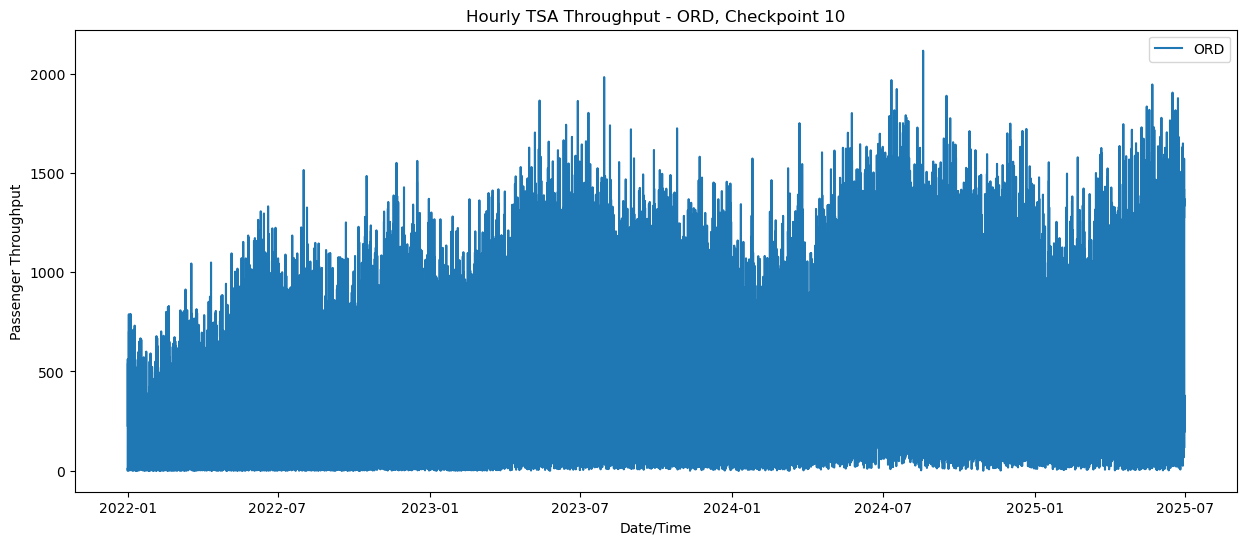

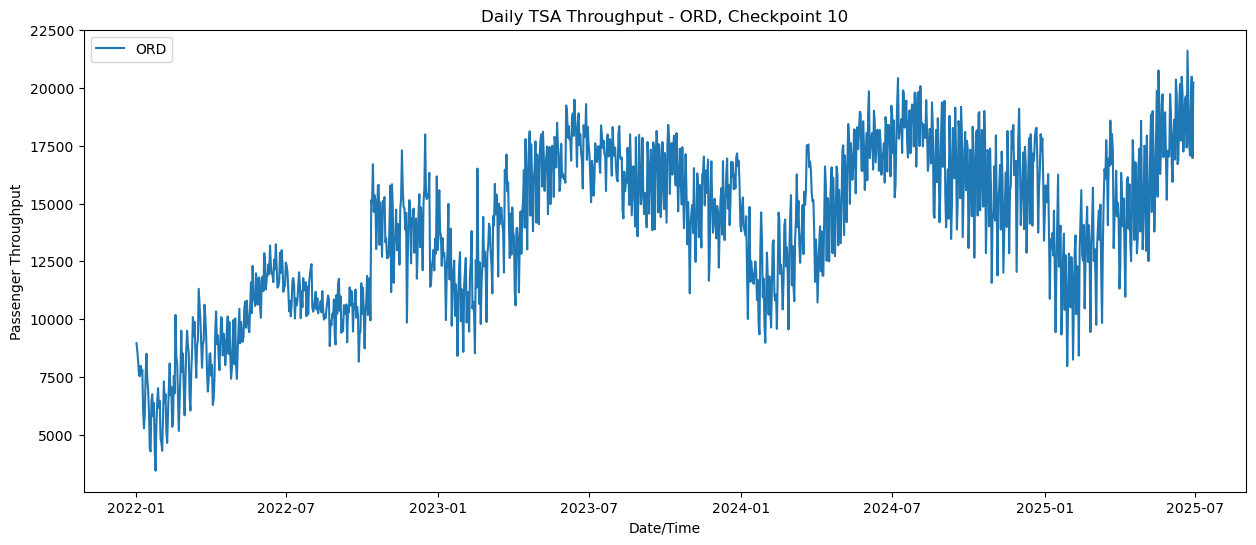

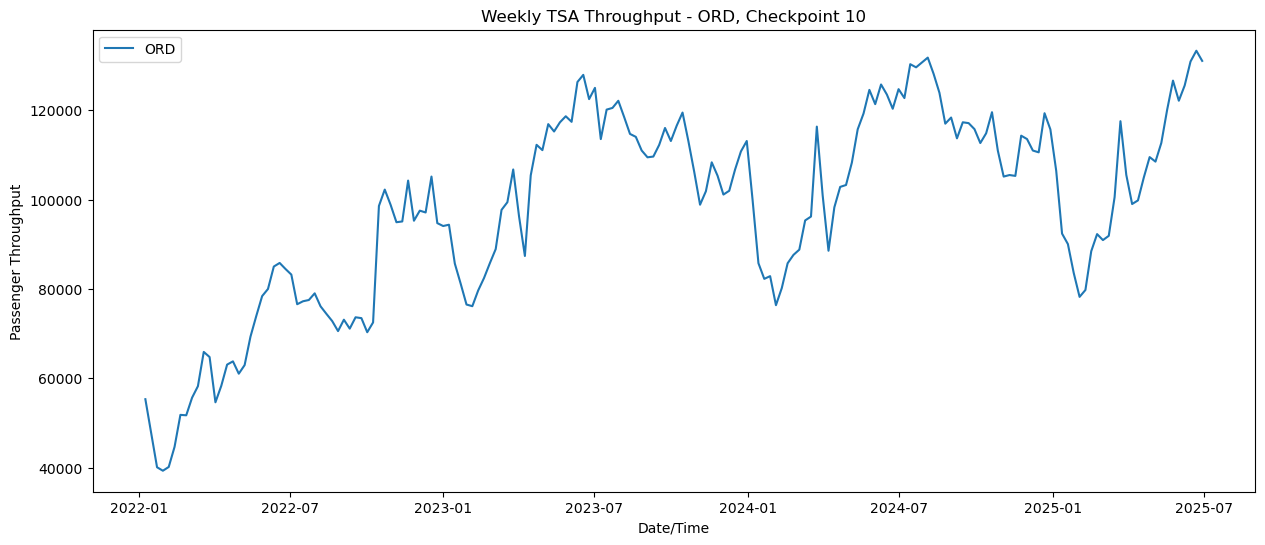

In [7]:
plot_airport_data(tsa_data, airport='ORD', frequency='H', checkpoint='10')
plot_airport_data(tsa_data, airport='ORD', frequency='D', checkpoint='10')
plot_airport_data(tsa_data, airport='ORD', frequency='W', checkpoint='10')

There are a few useful observations to make about this dataset. First of all, notice that the hourly data appears to be less useful than the daily and weekly data. Also notice that it is hard to observe a trend for the data from a single checkpoint, since this checkpoint may only be opened and closed during certain hours.

Next we can look at the airport as a whole:

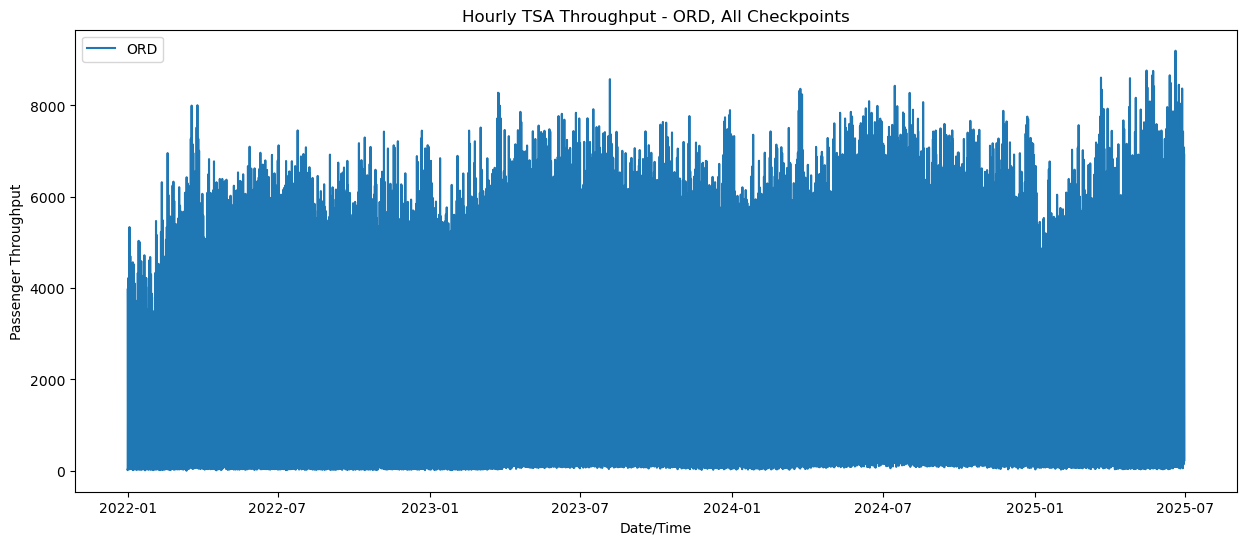

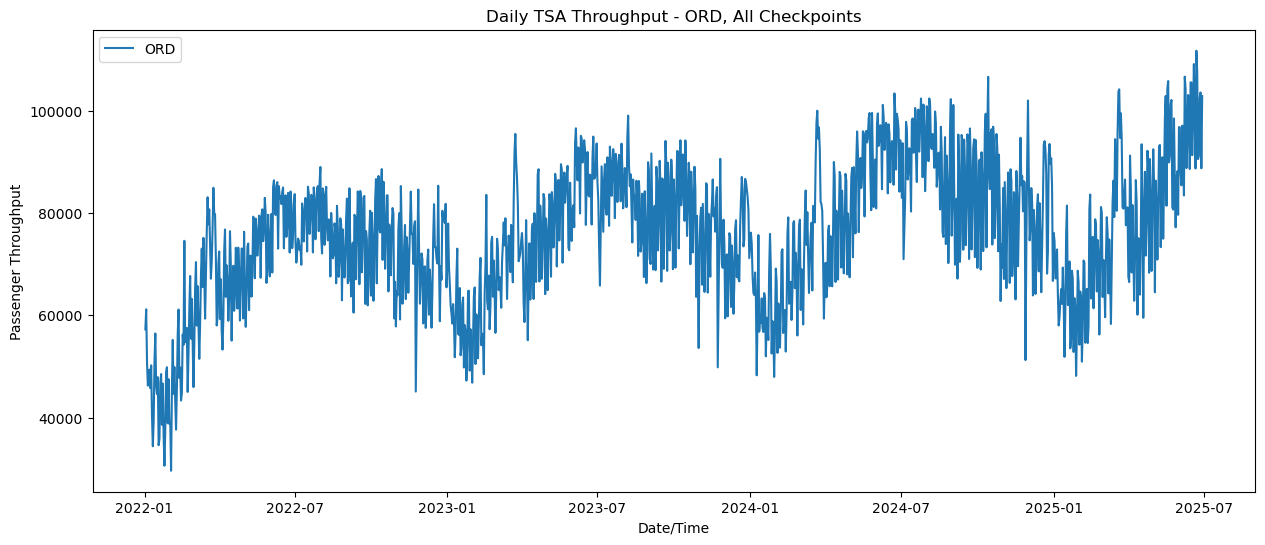

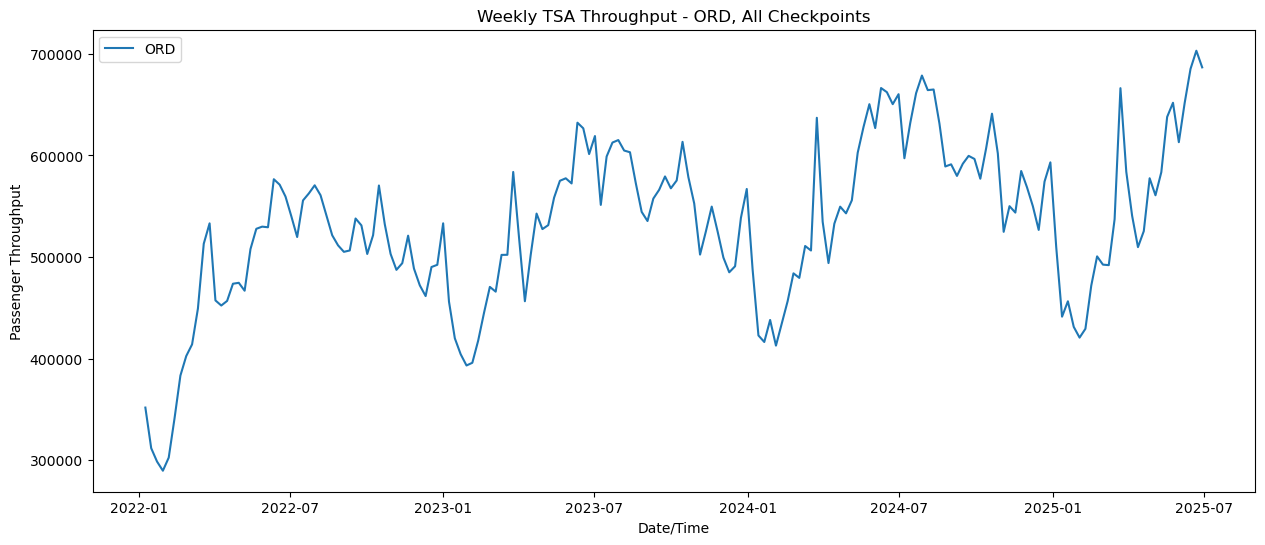

In [9]:
plot_airport_data(tsa_data, airport='ORD', frequency='H')
plot_airport_data(tsa_data, airport='ORD', frequency='D')
plot_airport_data(tsa_data, airport='ORD', frequency='W')